Dependencies installed!


<IPython.core.display.Javascript object>

Keep-alive activated, Colab won't disconnect during 30-min run

 Initializing benchmark
PARAMETERS:
  • Conversation lengths: [10, 20, 30, 40, 50]
  • Runs per setting: 200
  • Hybrid weights: 4 combinations
  • Plot DPI: 300
Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

Checkpoint saved: /content/benchmark_results/checkpoint_30/raw_results.csv (3600 rows)

Testing 40 turns...


Length 40: 100%|██████████| 200/200 [00:00<00:00, 301.93it/s]


Checkpoint saved: /content/benchmark_results/checkpoint_40/raw_results.csv (4800 rows)

Testing 50 turns...


Length 50: 100%|██████████| 200/200 [00:00<00:00, 269.60it/s]


Checkpoint saved: /content/benchmark_results/checkpoint_50/raw_results.csv (6000 rows)

RESULTS SUMMARY

 Overall Accuracy:
  hybrid_r0.3_s0.7         : 80.70%
  hybrid_r0.5_s0.5         : 80.20%
  hybrid_r0.7_s0.3         : 80.20%
  hybrid_r0.9_s0.1         : 80.20%
  latest                   : 80.20%
  similarity               : 80.00%

 Best Strategy: hybrid_r0.3_s0.7 (80.70%)

 Statistical significance (vs latest):
  t-statistic: 0.2818
  p-value: 0.7781
   Not significant

 Accuracy by Fact Type:
  hobby     : 81.02% (1512 samples)
  pet       : 84.76% (1542 samples)
  city      : 79.52% (1494 samples)
  color     : 75.41% (1452 samples)

 Memory Decay:
  After  1 turns: 95.63% (252 samples)
  After  6 turns: 87.00% (300 samples)
  After 11 turns: 93.75% (96 samples)
  After 16 turns: 82.61% (138 samples)
  After 21 turns: 83.33% (48 samples)
  After 26 turns: 69.23% (78 samples)
  After 31 turns: 81.67% (60 samples)
  After 36 turns: 73.08% (78 samples)
  After 41 turns: 66.67% (

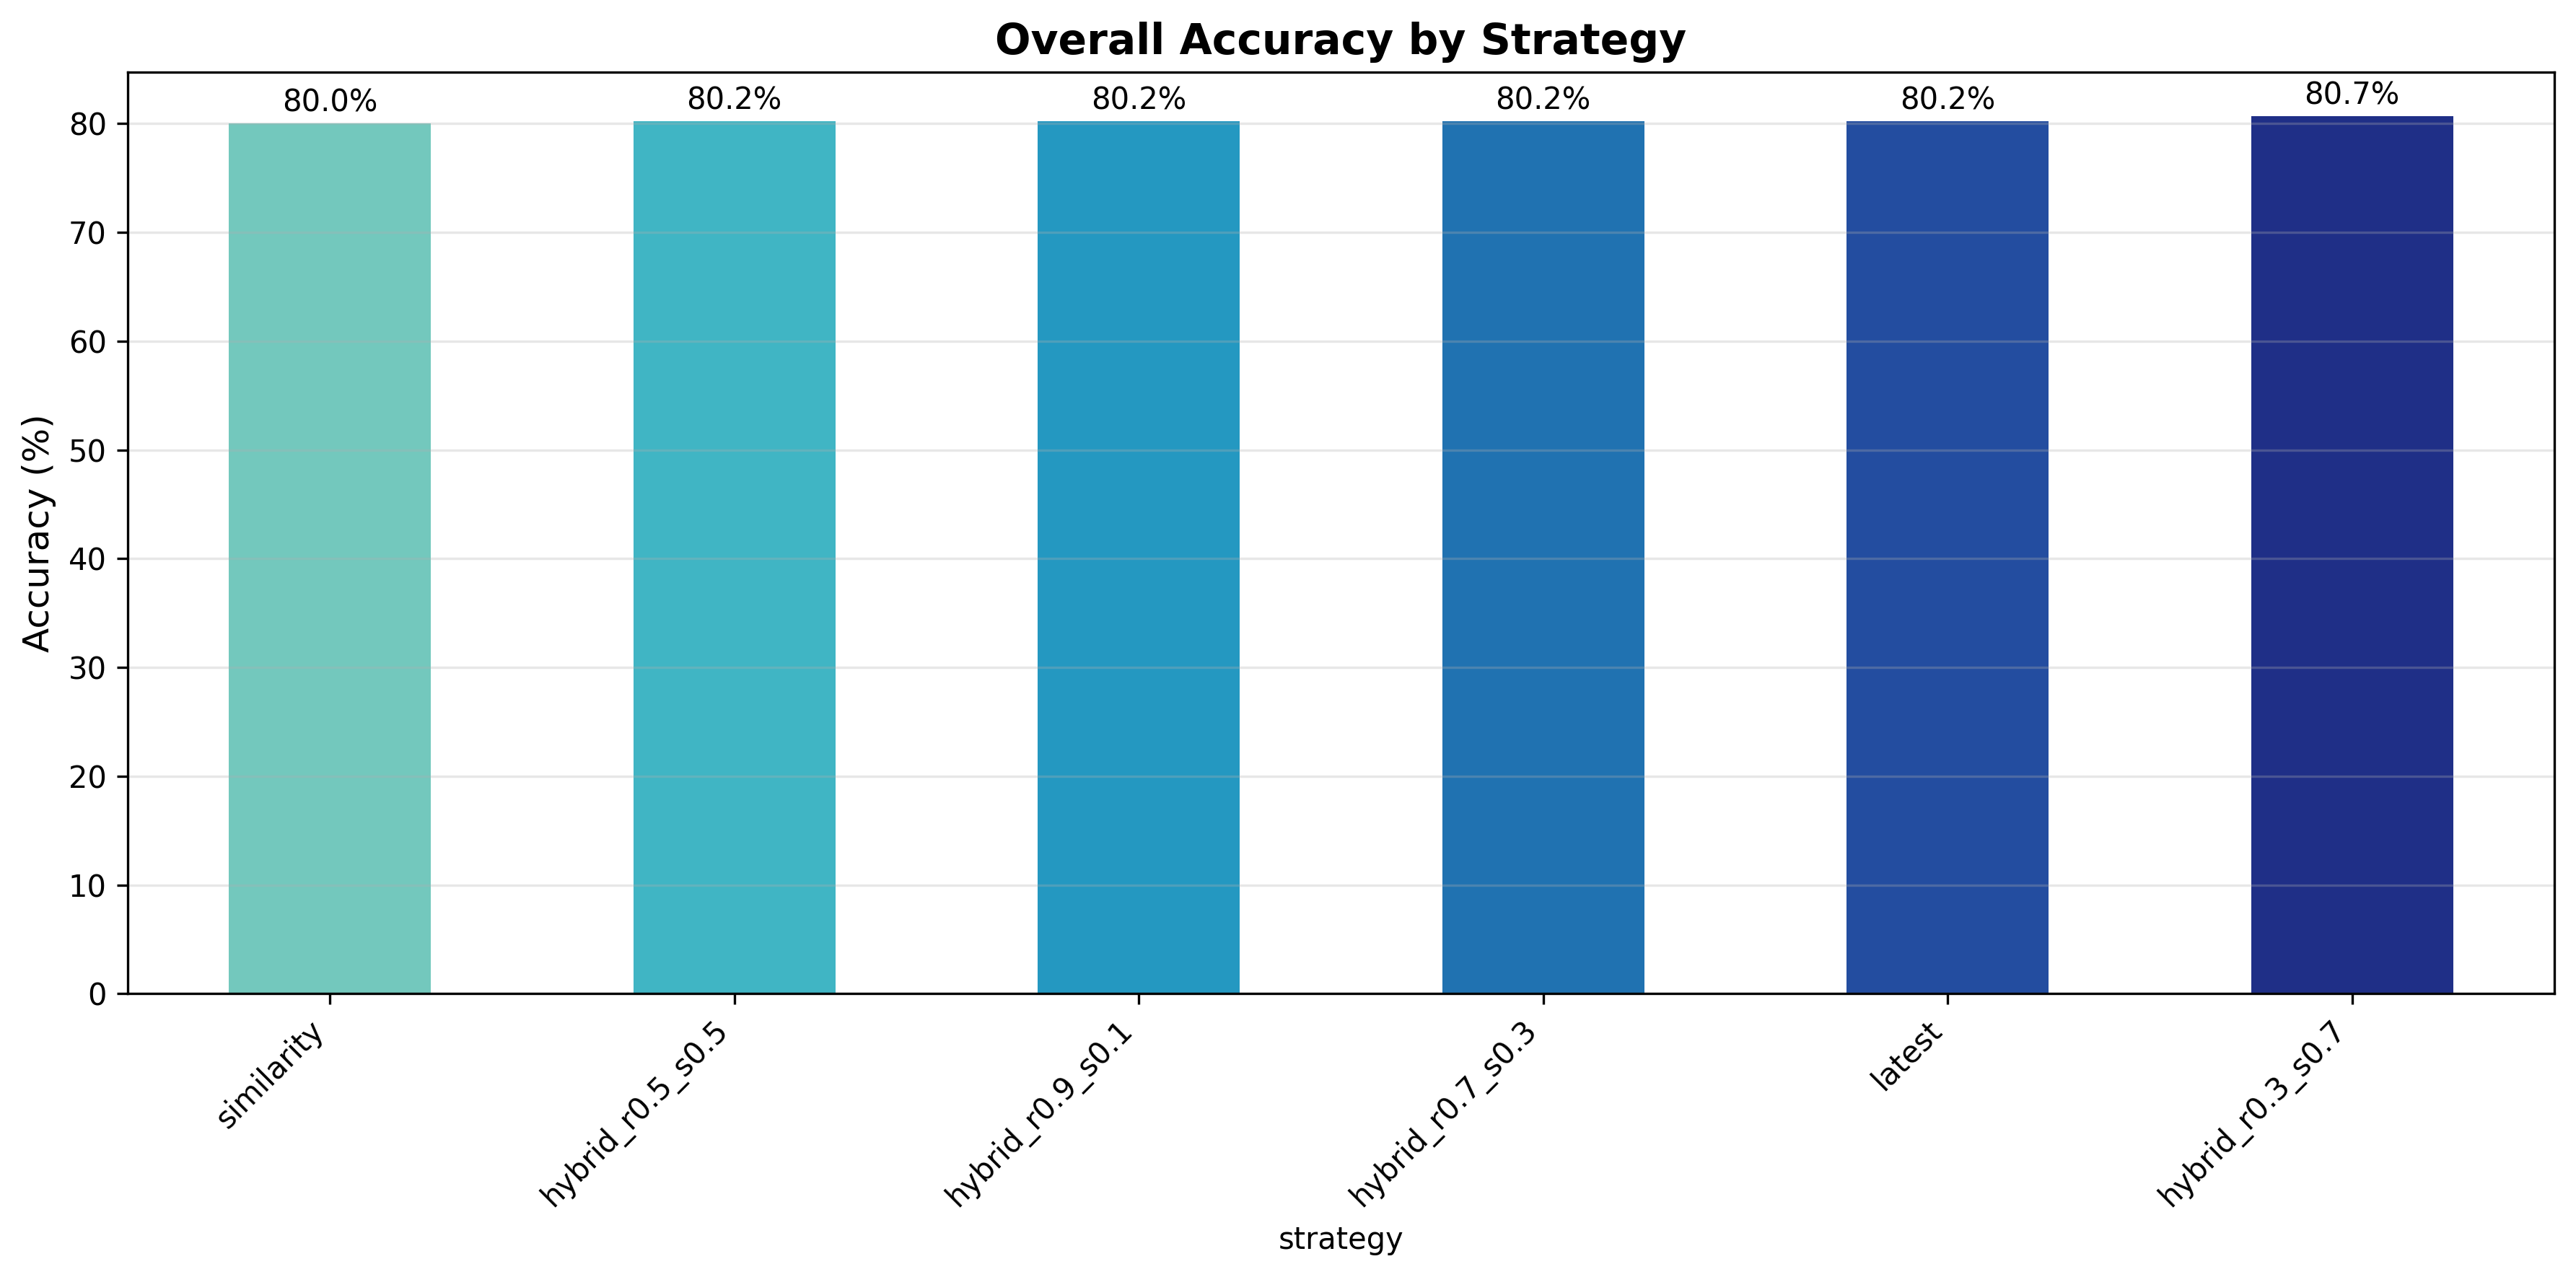

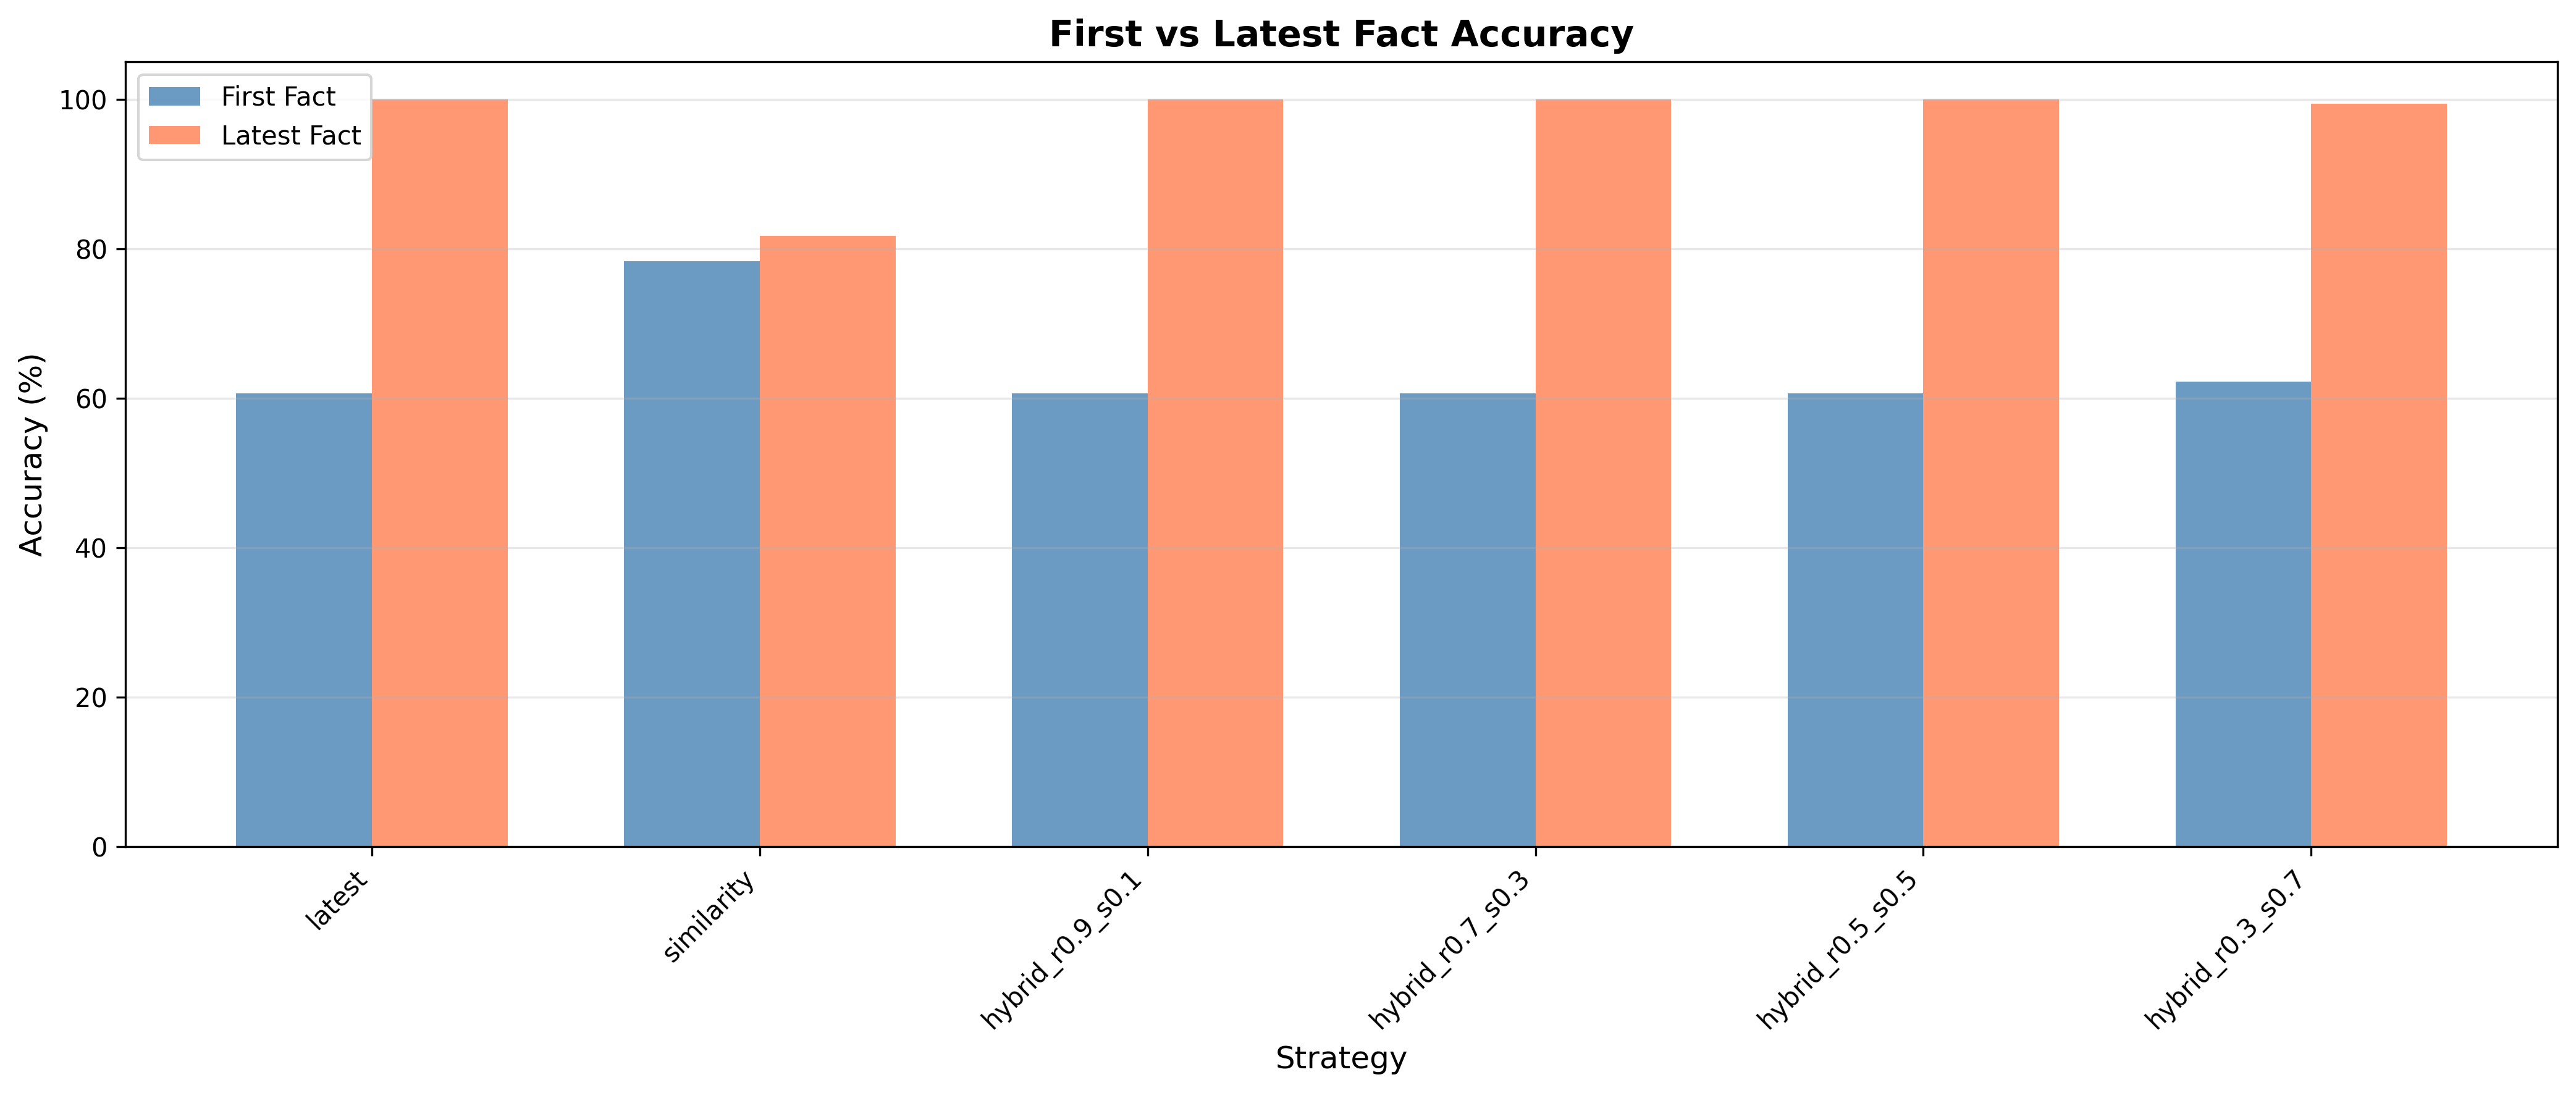

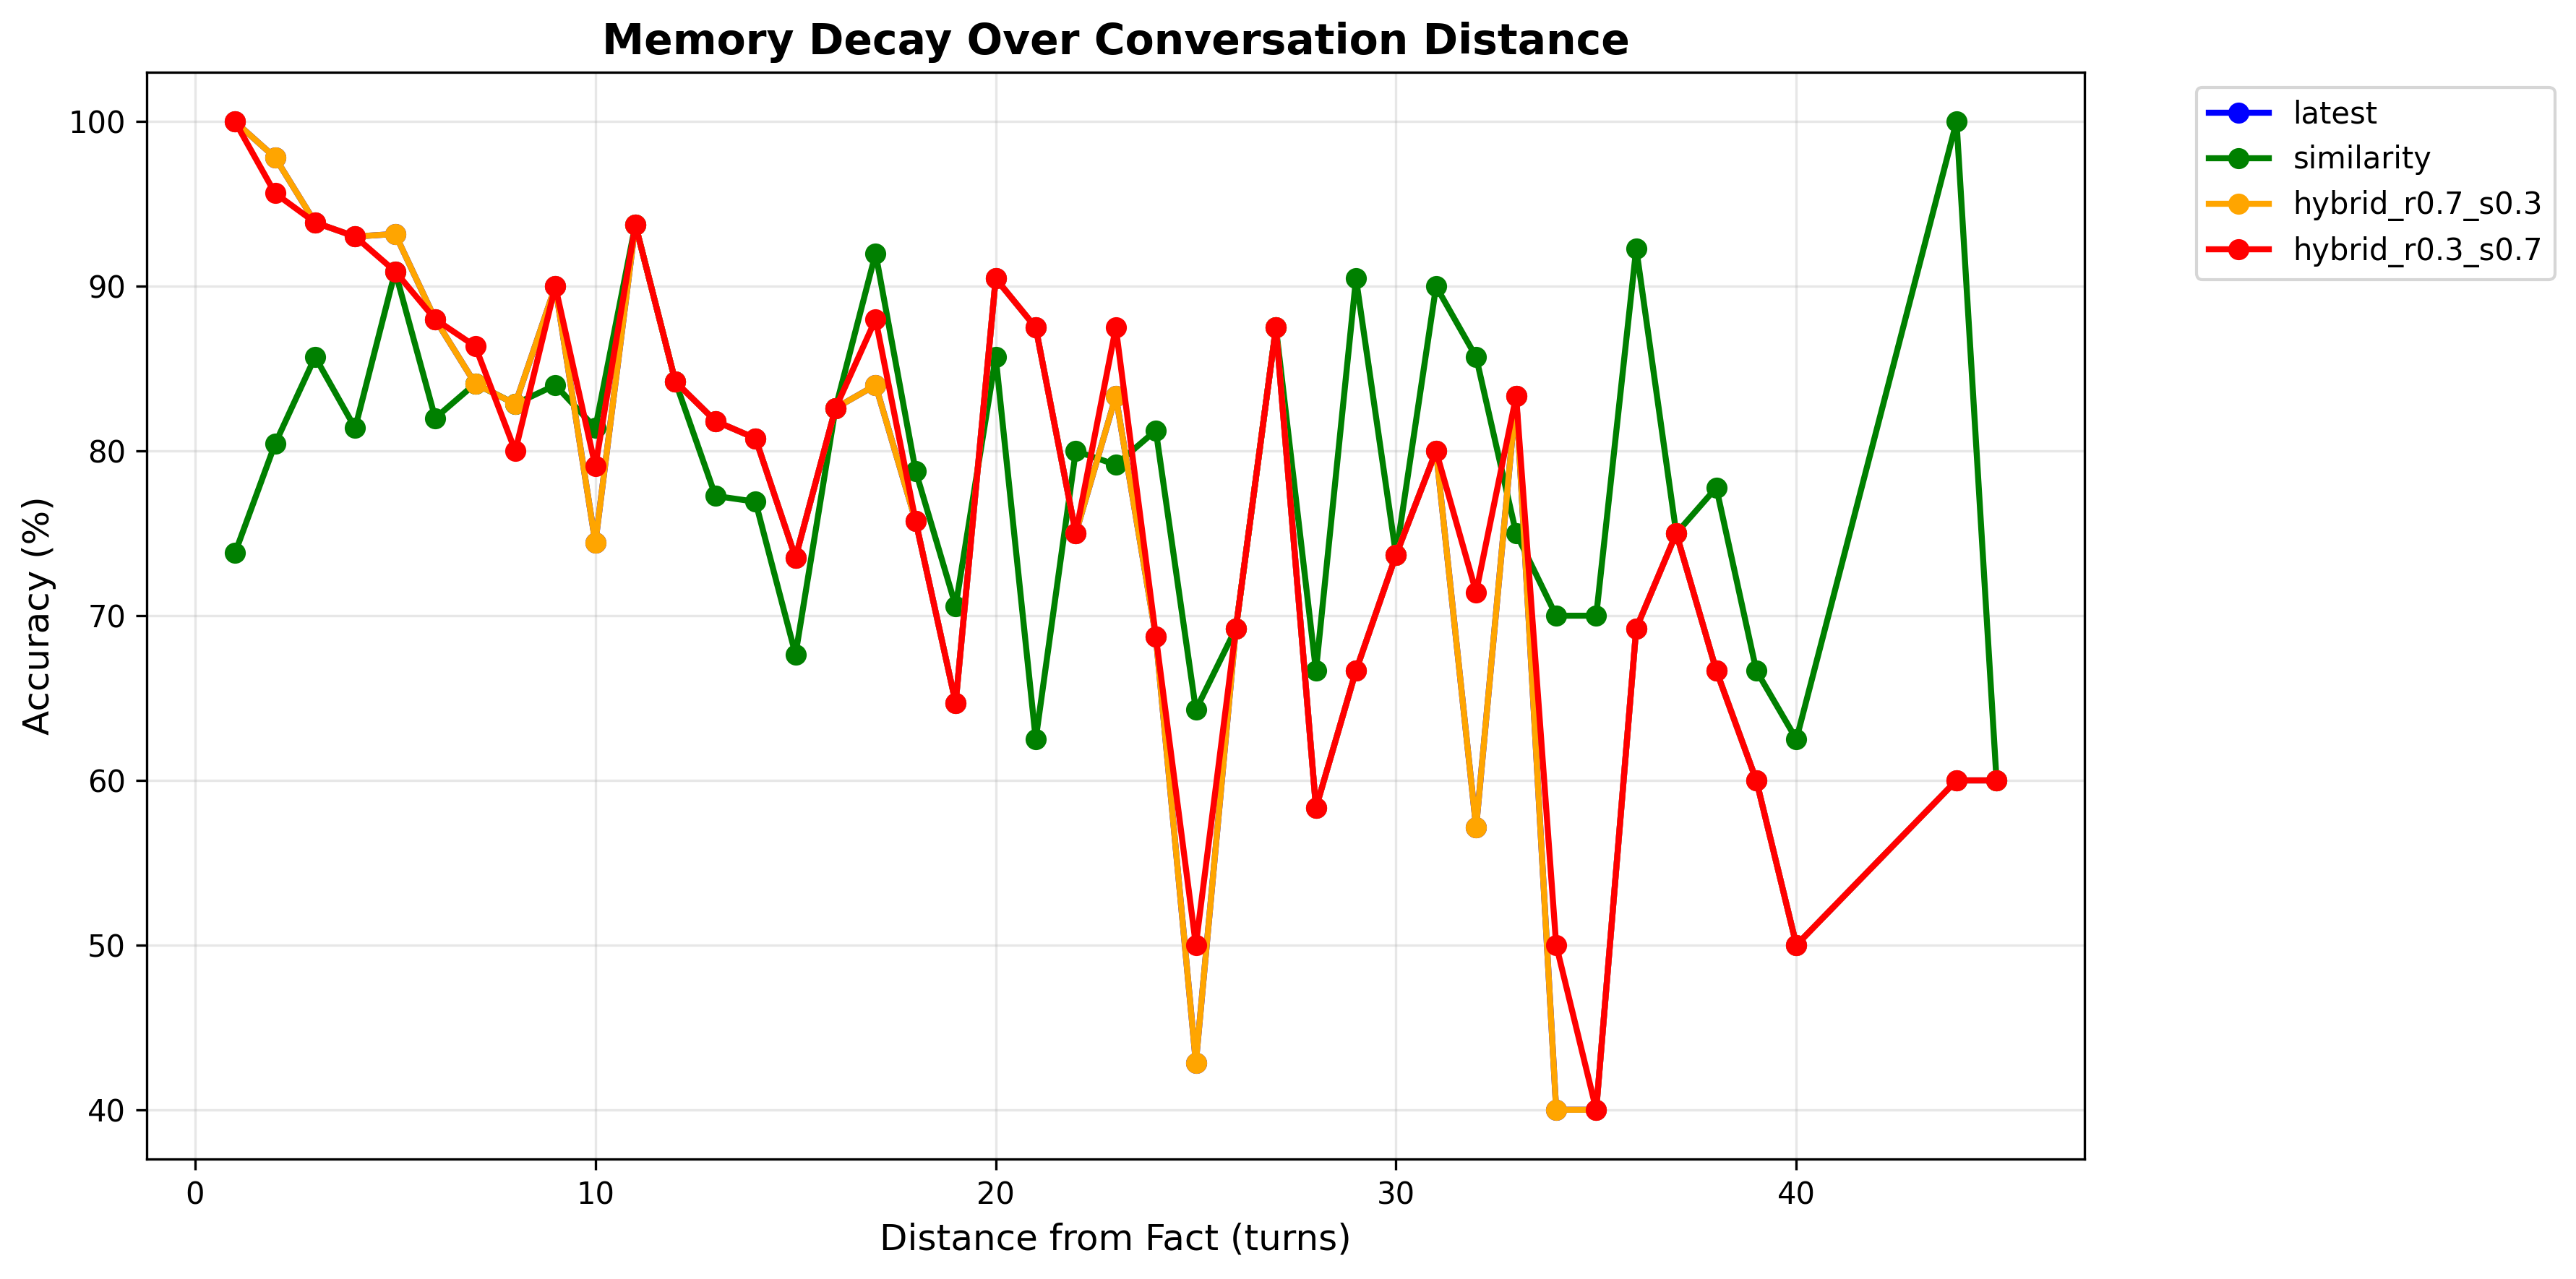

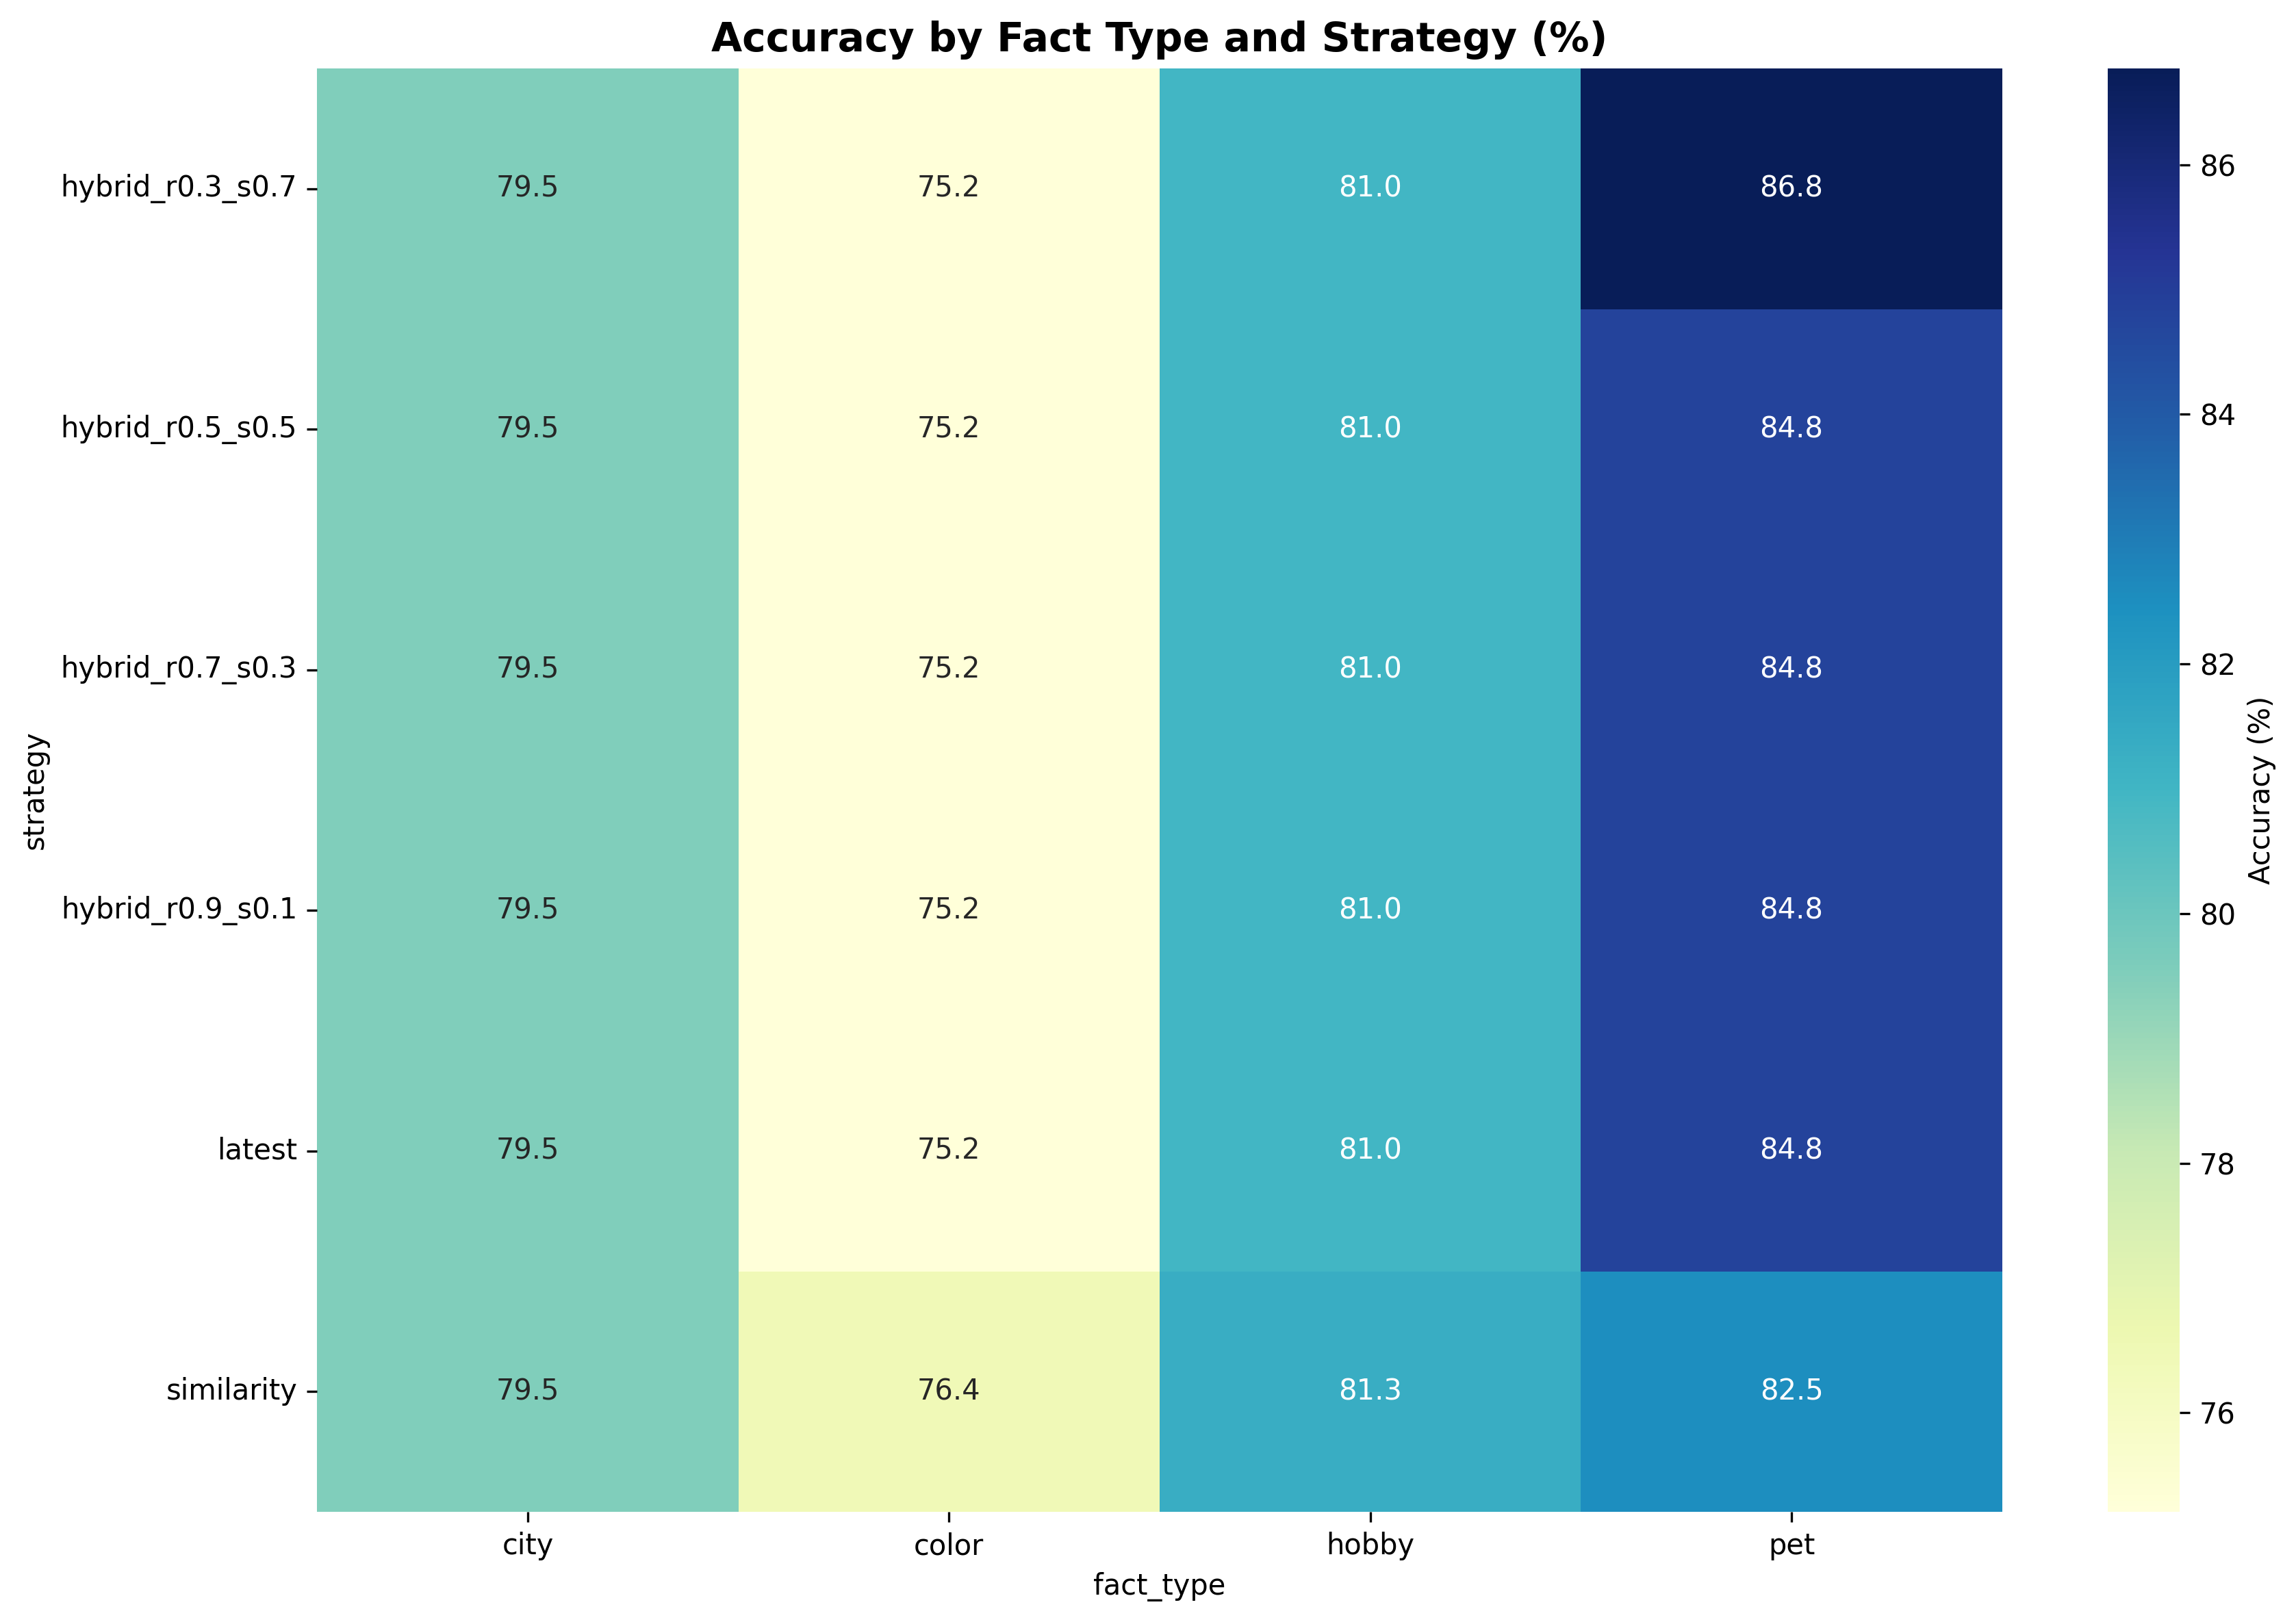

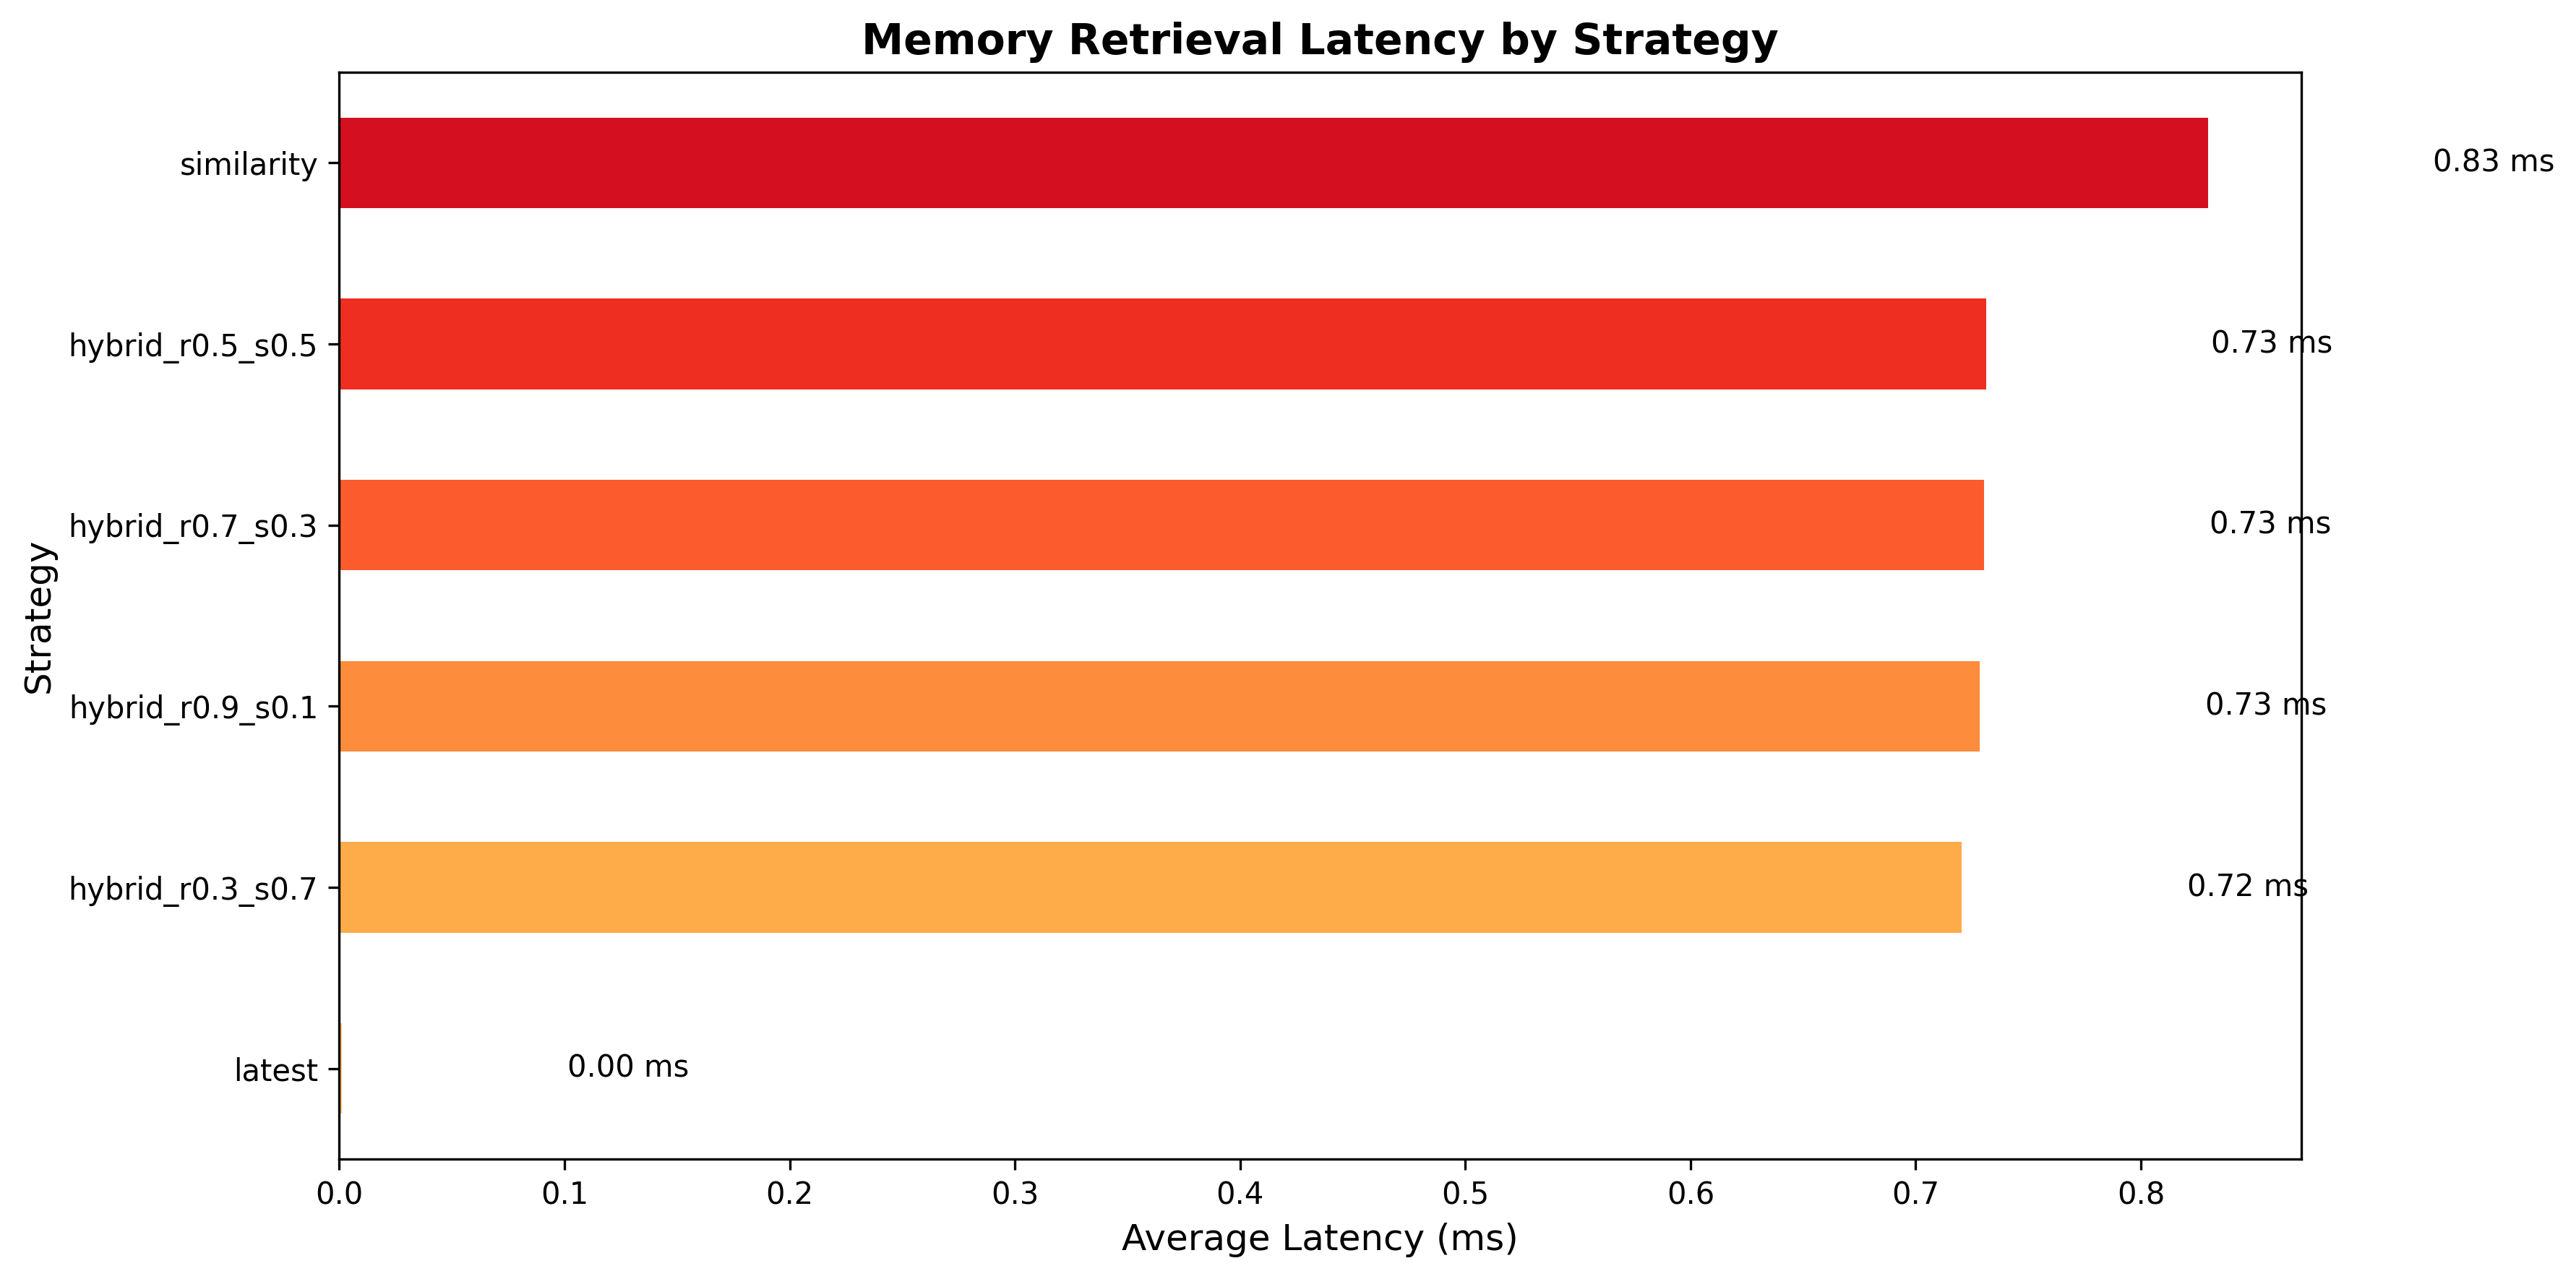

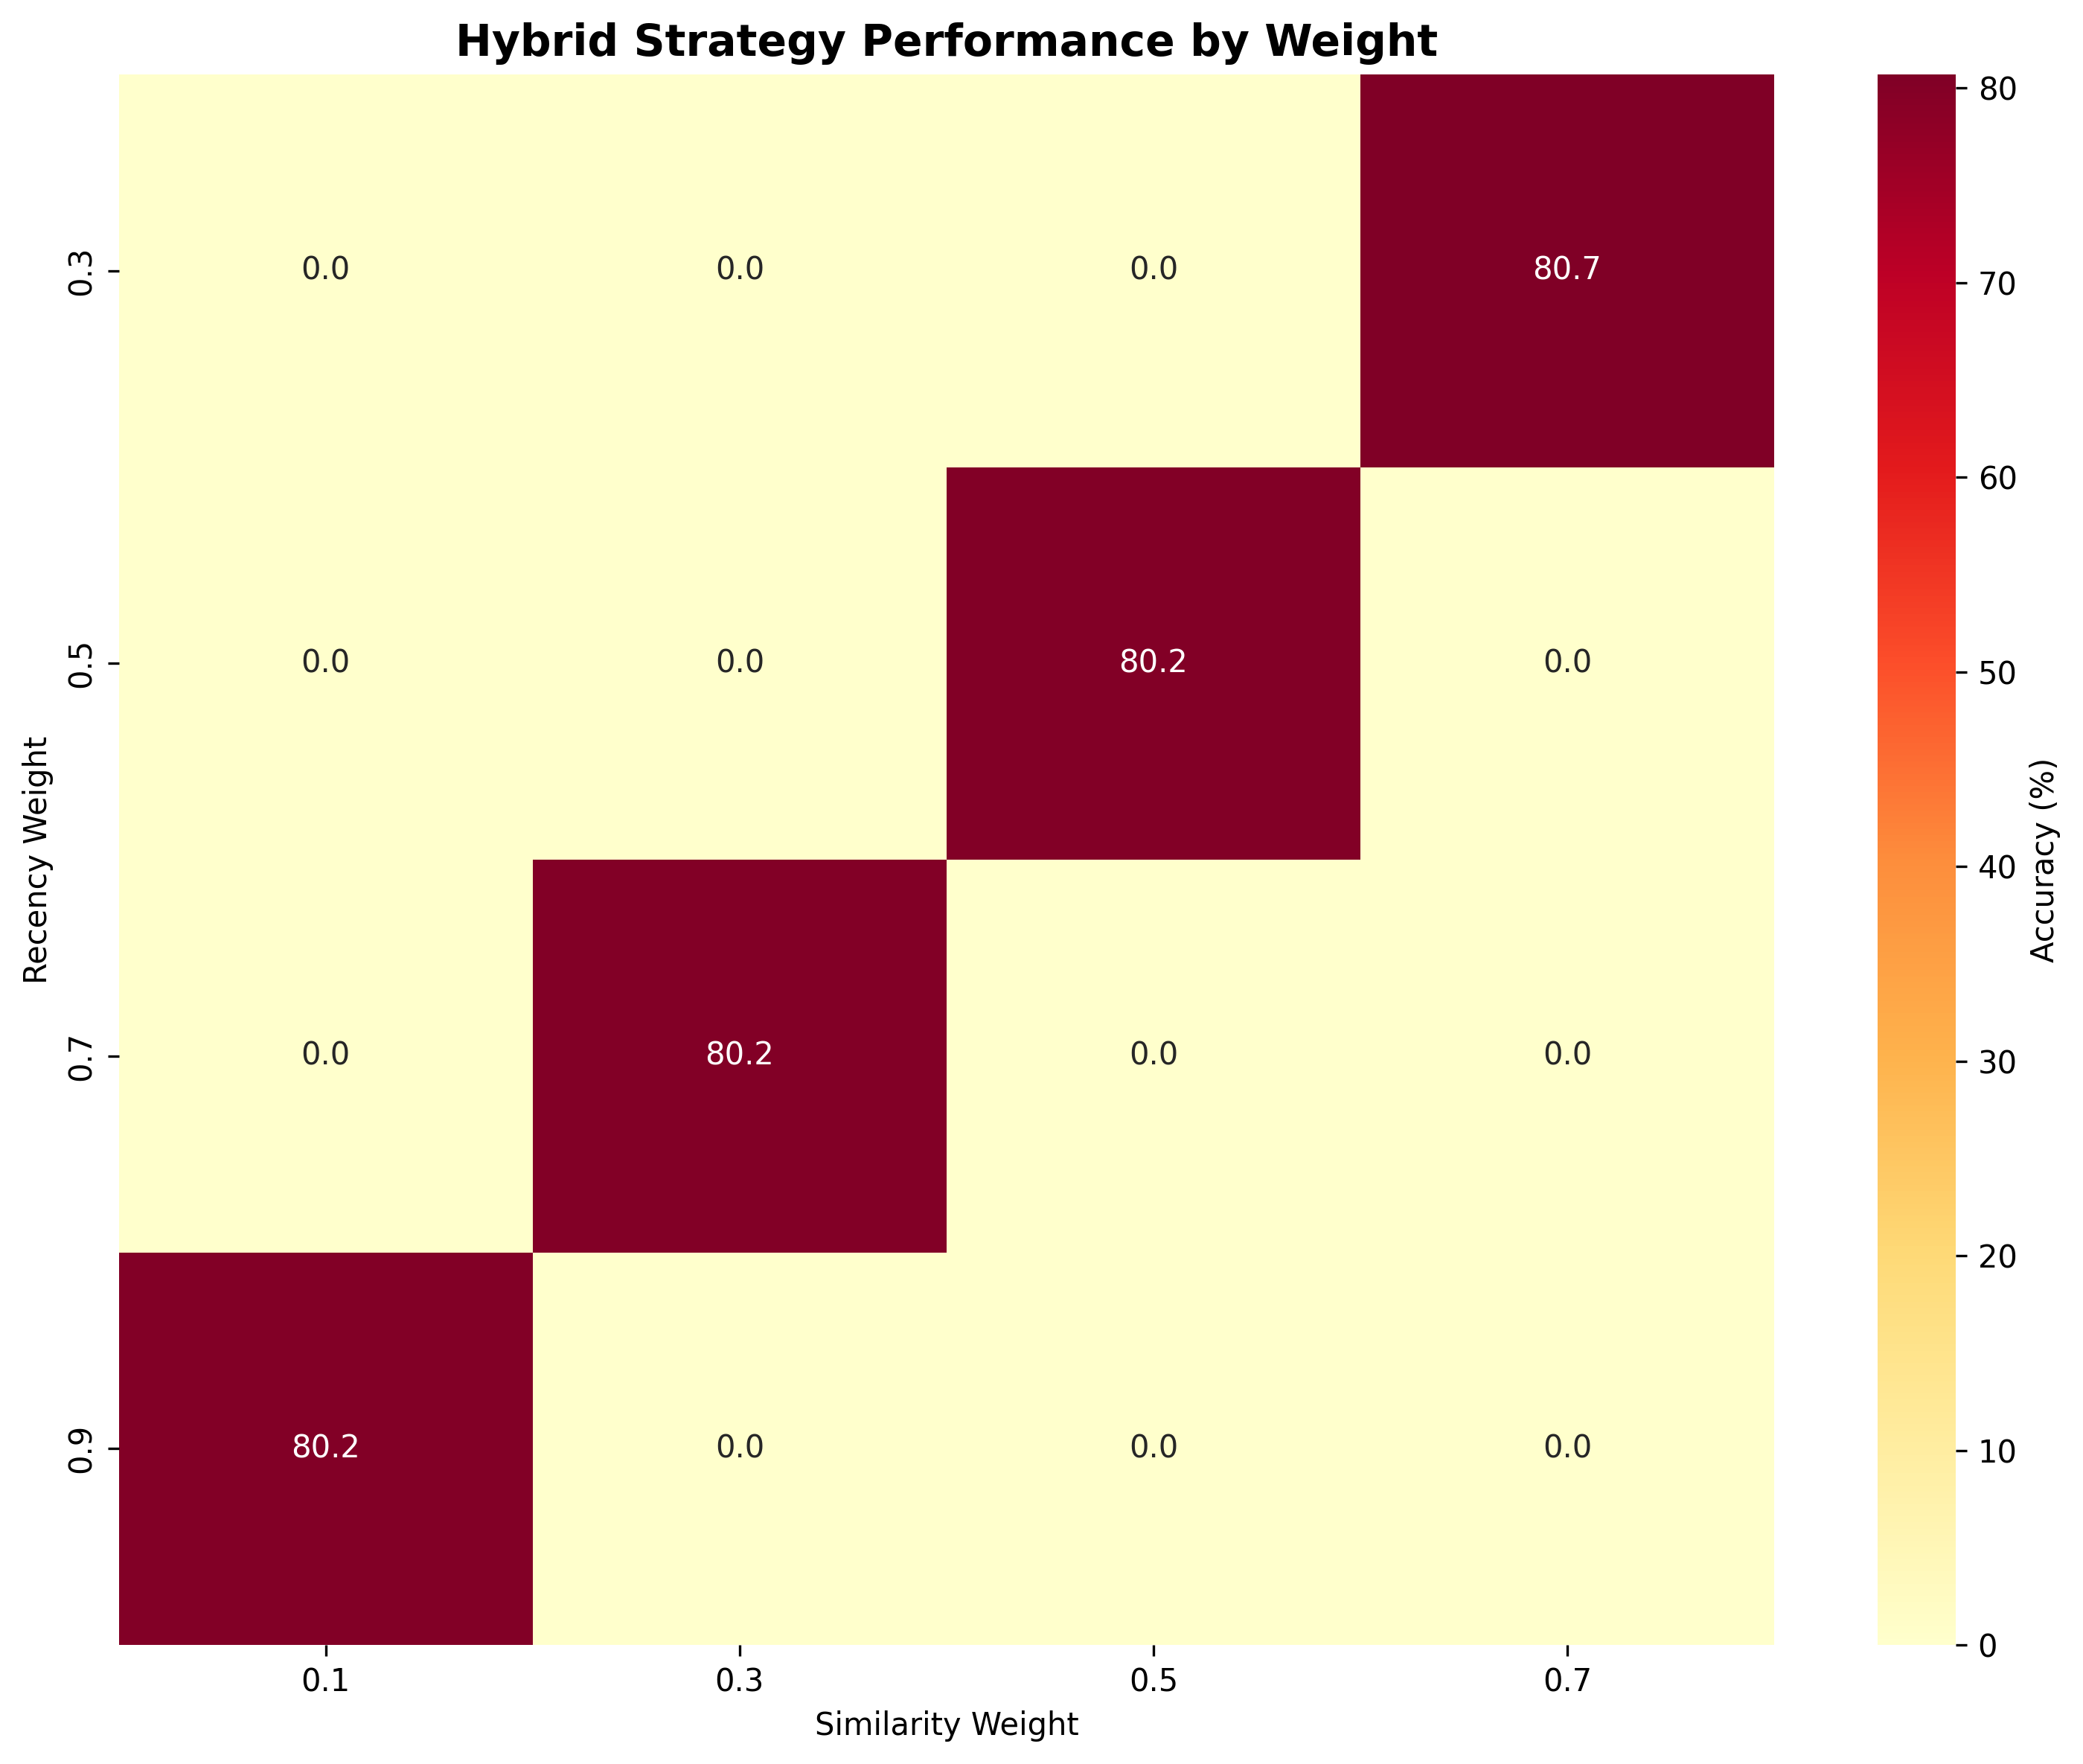

All plots saved to /content/benchmark_results/figures

 BENCHMARK COMPLETE

Results saved to: /content/benchmark_results
All data and plots are ready

 Created /content/benchmark_results_Phase1.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files included:
  - raw_results.csv - Complete dataset
  - figures/*.png - 6 high-resolution plots (300 DPI)
  - Checkpoint files for each conversation length


In [1]:
#Install Dependencies
!pip install sentence-transformers tqdm pyyaml scikit-learn seaborn -q

print("Dependencies installed!")

#Keep Colab Alive

import IPython
from IPython.display import display, Javascript

def keep_alive():
    display(Javascript("""
        function ClickConnect(){
            console.log("Working");
            document.querySelector("colab-toolbar-button#connect").click()
        }
        setInterval(ClickConnect, 60000)
    """))#

keep_alive()
print("Keep-alive activated, Colab won't disconnect during 30-min run")

#Full Benchmark Code

import random
import time
import json
import yaml
import hashlib
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any, Union
from dataclasses import dataclass, asdict, field
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

#Reproducibility
random.seed(42)
np.random.seed(42)
#print("Random seed fixed to 42 - results will be reproducible")

#Configuration

@dataclass
class BenchmarkConfig:
    """Configuration for the benchmark run."""
    conversation_lengths: List[int] = None
    runs_per_setting: int = 200
    hybrid_weights: List[Tuple[float, float]] = None
    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    similarity_threshold: float = 0.8
    fact_types: Dict[str, List[str]] = None
    output_dir: str = "/content/benchmark_results"
    save_plots: bool = True
    save_data: bool = True
    plot_dpi: int = 300

    def __post_init__(self):
        if self.conversation_lengths is None:
            self.conversation_lengths = [10, 20, 30, 40, 50]
        if self.hybrid_weights is None:
            self.hybrid_weights = [(0.9,0.1), (0.7,0.3), (0.5,0.5), (0.3,0.7)]
        if self.fact_types is None:
            self.fact_types = {
                "color": ["red", "blue", "green", "yellow", "purple"],
                "hobby": ["reading", "gaming", "painting", "soccer", "cooking"],
                "pet": ["dog", "cat", "hamster", "fish", "parrot"],
                "city": ["Paris", "London", "Tokyo", "New York", "Berlin"]
            }


@dataclass
class Fact:
    """Represents a single fact in the conversation."""
    fact_type: str
    value: str
    turn: int
    embedding: Optional[np.ndarray] = None
    context: Optional[str] = None


@dataclass
class Turn:
    """Represents a single conversation turn."""
    speaker: str
    text: str
    facts: List[Fact] = field(default_factory=list)


@dataclass
class Probe:
    """Represents a probe question to test memory."""
    question: str
    fact_type: str
    expected_value: str
    fact_turn: int
    probe_turn: int
    is_first: bool

    @property
    def distance(self) -> int:
        return self.probe_turn - self.fact_turn


@dataclass
class ExperimentResult:
    """Results from a single experimental run."""
    strategy_name: str
    correct: bool
    latency_ms: float
    fact_type: str
    distance: int
    is_first: bool
    conversation_length: int

#Embedding Manager

class EmbeddingManager:
    """Manages embeddings for semantic similarity."""

    def __init__(self, model_name: str):
        self.model_name = model_name
        self.model = None
        self.cache = {}
        print(f"Loading embedding model: {model_name}")
        self._load_model()

    def _load_model(self):
        self.model = SentenceTransformer(self.model_name)

    def encode(self, text: str) -> np.ndarray:
        if text in self.cache:
            return self.cache[text].copy()
        embedding = self.model.encode(text)
        self.cache[text] = embedding.copy()
        return embedding

    def similarity(self, text1: str, text2: str) -> float:
        emb1 = self.encode(text1).reshape(1, -1)
        emb2 = self.encode(text2).reshape(1, -1)
        return float(cosine_similarity(emb1, emb2)[0, 0])

    def similarity_embeddings(self, emb1: np.ndarray, emb2: np.ndarray) -> float:
        emb1 = emb1.reshape(1, -1)
        emb2 = emb2.reshape(1, -1)
        return float(cosine_similarity(emb1, emb2)[0, 0])

#Conversation Generator

class ConversationGenerator:
    """Generates realistic test conversations."""

    def __init__(self, config: BenchmarkConfig, embedding_manager: EmbeddingManager):
        self.config = config
        self.embedding_manager = embedding_manager

        self.fact_templates = {
            "color": [
                "I've always loved {value}.",
                "My favorite color is {value}.",
                "I painted my room {value}."
            ],
            "hobby": [
                "In my free time, I enjoy {value}.",
                "My favorite hobby is {value}.",
                "I love {value}."
            ],
            "pet": [
                "I have a {value}.",
                "My {value} is my best friend.",
                "I'm a {value} person."
            ],
            "city": [
                "I'm from {value}.",
                "My favorite city is {value}.",
                "I lived in {value}."
            ]
        }

        self.filler_templates = [
            "That's interesting!",
            "Tell me more.",
            "I see.",
            "Oh really?",
            "Anyway...",
            "Good point!"
        ]

    def generate_fact_turn(self, fact_type: str, value: str, turn_num: int) -> Tuple[str, Fact]:
        template = random.choice(self.fact_templates[fact_type])
        sentence = template.format(value=value)

        fact = Fact(
            fact_type=fact_type,
            value=value,
            turn=turn_num,
            embedding=self.embedding_manager.encode(value),
            context=sentence
        )

        return sentence, fact

    def generate_filler_turn(self) -> str:
        return random.choice(self.filler_templates)

    def generate_conversation(self, turns: int) -> Tuple[List[Turn], Optional[Probe]]:
        conversation = []
        facts_by_type = defaultdict(list)

        #Distribute facts throughout conversation
        num_facts = min(4, turns // 3)
        if num_facts == 0:
            num_facts = 1

        fact_positions = sorted(random.sample(range(turns), k=num_facts))

        for turn_num in range(turns):
            if turn_num in fact_positions:
                fact_type = random.choice(list(self.config.fact_types.keys()))
                value = random.choice(self.config.fact_types[fact_type])
                sentence, fact = self.generate_fact_turn(fact_type, value, turn_num)
                facts_by_type[fact_type].append(fact)
                turn = Turn(speaker="user", text=sentence, facts=[fact])
            else:
                sentence = self.generate_filler_turn()
                turn = Turn(speaker="user", text=sentence, facts=[])

            conversation.append(turn)

        # Select a fact to probe
        if not facts_by_type:
            return conversation, None

        fact_type = random.choice(list(facts_by_type.keys()))
        facts = facts_by_type[fact_type]

        ask_first = random.random() < 0.5

        if ask_first:
            target_fact = facts[0]
            question = f"What was my first {fact_type}?"
        else:
            target_fact = facts[-1]
            question = f"What is my latest {fact_type}?"

        probe = Probe(
            question=question,
            fact_type=fact_type,
            expected_value=target_fact.value,
            fact_turn=target_fact.turn,
            probe_turn=turns,
            is_first=ask_first
        )

        return conversation, probe


#Memory Strategies

class BaseMemoryStrategy:
    """Abstract base class for memory strategies."""

    def __init__(self, name: str, embedding_manager: EmbeddingManager):
        self.name = name
        self.embedding_manager = embedding_manager
        self.reset()

    def reset(self):
        self.memory = defaultdict(list)
        self.total_latency = 0
        self.calls = 0

    def observe_fact(self, fact: Fact):
        self.memory[fact.fact_type].append({
            "value": fact.value,
            "embedding": fact.embedding,
            "turn": fact.turn,
            "context": fact.context
        })

    def retrieve(self, fact_type: str, query: str) -> Optional[str]:
        start = time.time()
        result = self._retrieve_impl(fact_type, query)
        self.total_latency += (time.time() - start) * 1000
        self.calls += 1
        return result

    def _retrieve_impl(self, fact_type: str, query: str) -> Optional[str]:
        raise NotImplementedError

    def get_average_latency(self) -> float:
        return self.total_latency / max(self.calls, 1)


class LatestMemoryStrategy(BaseMemoryStrategy):
    def __init__(self, embedding_manager: EmbeddingManager):
        super().__init__("latest", embedding_manager)

    def _retrieve_impl(self, fact_type: str, query: str) -> Optional[str]:
        if fact_type not in self.memory or not self.memory[fact_type]:
            return None
        return self.memory[fact_type][-1]["value"]


class SimilarityMemoryStrategy(BaseMemoryStrategy):
    def __init__(self, embedding_manager: EmbeddingManager):
        super().__init__("similarity", embedding_manager)

    def _retrieve_impl(self, fact_type: str, query: str) -> Optional[str]:
        if fact_type not in self.memory or not self.memory[fact_type]:
            return None

        query_emb = self.embedding_manager.encode(query)
        best_sim = -1
        best_value = None

        for item in self.memory[fact_type]:
            sim = self.embedding_manager.similarity_embeddings(query_emb, item["embedding"])
            if sim > best_sim:
                best_sim = sim
                best_value = item["value"]

        return best_value


class HybridMemoryStrategy(BaseMemoryStrategy):
    def __init__(self, recency_weight: float, similarity_weight: float,
                 embedding_manager: EmbeddingManager):
        name = f"hybrid_r{recency_weight:.1f}_s{similarity_weight:.1f}"
        super().__init__(name, embedding_manager)
        self.recency_weight = recency_weight
        self.similarity_weight = similarity_weight

    def _retrieve_impl(self, fact_type: str, query: str) -> Optional[str]:
        if fact_type not in self.memory or not self.memory[fact_type]:
            return None

        query_emb = self.embedding_manager.encode(query)
        n = len(self.memory[fact_type])
        best_score = -1
        best_value = None

        for i, item in enumerate(self.memory[fact_type]):
            recency_score = (i + 1) / n
            sim = self.embedding_manager.similarity_embeddings(query_emb, item["embedding"])
            score = self.recency_weight * recency_score + self.similarity_weight * sim

            if score > best_score:
                best_score = score
                best_value = item["value"]

        return best_value

#Evaluator

class Evaluator:
    def __init__(self, embedding_manager: EmbeddingManager):
        self.embedding_manager = embedding_manager

    def evaluate(self, response: Optional[str], expected: str) -> bool:
        if response is None:
            return False
        return response.lower().strip() == expected.lower().strip()

#Experiment Tracker

class ExperimentTracker:
    def __init__(self, config: BenchmarkConfig):
        self.config = config
        self.results: List[ExperimentResult] = []

    def log_result(self, result: ExperimentResult):
        self.results.append(result)

    def get_dataframe(self) -> pd.DataFrame:
        data = []
        for r in self.results:
            data.append({
                "strategy": r.strategy_name,
                "correct": r.correct,
                "latency_ms": r.latency_ms,
                "fact_type": r.fact_type,
                "distance": r.distance,
                "is_first": r.is_first,
                "conversation_length": r.conversation_length
            })
        return pd.DataFrame(data)

    def save(self, output_dir: Path):
        output_dir.mkdir(parents=True, exist_ok=True)
        df = self.get_dataframe()
        df.to_csv(output_dir / "raw_results.csv", index=False)

        # Save checkpoint notification
        print(f"Checkpoint saved: {output_dir}/raw_results.csv ({len(df)} rows)")

#Visualisation

class Visualizer:
    def __init__(self, output_dir: Path, dpi: int = 300):
        self.output_dir = output_dir
        self.dpi = dpi
        self.output_dir.mkdir(parents=True, exist_ok=True)
        plt.style.use('default')

    def plot_all(self, df: pd.DataFrame):
        """Create all visualizations."""

        #Overall Accuracy
        plt.figure(figsize=(12, 6), dpi=self.dpi)
        acc_df = df.groupby('strategy')['correct'].mean().sort_values() * 100
        colors = plt.cm.YlGnBu(np.linspace(0.4, 0.9, len(acc_df)))
        acc_df.plot(kind='bar', color=colors)
        plt.title('Overall Accuracy by Strategy', fontsize=14, fontweight='bold')
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y')

        #Add value labels
        for i, v in enumerate(acc_df.values):
            plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.savefig(self.output_dir / 'overall_accuracy.png', dpi=self.dpi, bbox_inches='tight')
        plt.show()

        #First vs Latest
        plt.figure(figsize=(14, 6), dpi=self.dpi)
        strategies = df['strategy'].unique()
        first_acc = []
        latest_acc = []

        for strategy in strategies:
            strat_df = df[df['strategy'] == strategy]
            first_acc.append(strat_df[strat_df['is_first'] == True]['correct'].mean() * 100 if len(strat_df[strat_df['is_first'] == True]) > 0 else 0)
            latest_acc.append(strat_df[strat_df['is_first'] == False]['correct'].mean() * 100 if len(strat_df[strat_df['is_first'] == False]) > 0 else 0)

        x = np.arange(len(strategies))
        width = 0.35
        plt.bar(x - width/2, first_acc, width, label='First Fact', alpha=0.8, color='steelblue')
        plt.bar(x + width/2, latest_acc, width, label='Latest Fact', alpha=0.8, color='coral')
        plt.xlabel('Strategy', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.title('First vs Latest Fact Accuracy', fontsize=14, fontweight='bold')
        plt.xticks(x, strategies, rotation=45, ha='right')
        plt.legend()
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(self.output_dir / 'first_vs_latest.png', dpi=self.dpi, bbox_inches='tight')
        plt.show()

        #Memory Decay
        plt.figure(figsize=(12, 6), dpi=self.dpi)
        strategies_to_plot = ['latest', 'similarity', 'hybrid_r0.7_s0.3', 'hybrid_r0.3_s0.7']
        colors = ['blue', 'green', 'orange', 'red']

        for strategy, color in zip(strategies_to_plot, colors):
            if strategy in df['strategy'].unique():
                strat_df = df[df['strategy'] == strategy]
                decay_data = []
                distances = sorted(df['distance'].unique())
                valid_distances = []
                for dist in distances:
                    dist_df = strat_df[strat_df['distance'] == dist]
                    if len(dist_df) >= 5:  # Only plot if enough samples
                        decay_data.append(dist_df['correct'].mean() * 100)
                        valid_distances.append(dist)
                if decay_data:
                    plt.plot(valid_distances, decay_data, marker='o', linewidth=2,
                            label=strategy, color=color, markersize=6)

        plt.xlabel('Distance from Fact (turns)', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.title('Memory Decay Over Conversation Distance', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(self.output_dir / 'memory_decay.png', dpi=self.dpi, bbox_inches='tight')
        plt.show()

        #Fact Type Performance Heatmap
        plt.figure(figsize=(12, 8), dpi=self.dpi)
        pivot = df.pivot_table(
            values='correct',
            index='strategy',
            columns='fact_type',
            aggfunc='mean',
            fill_value=0
        ) * 100
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
                   cbar_kws={'label': 'Accuracy (%)'})
        plt.title('Accuracy by Fact Type and Strategy (%)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(self.output_dir / 'fact_type_performance.png', dpi=self.dpi, bbox_inches='tight')
        plt.show()

        #Latency Comparison
        plt.figure(figsize=(12, 6), dpi=self.dpi)
        latency_df = df.groupby('strategy')['latency_ms'].mean().sort_values()
        colors = plt.cm.YlOrRd(np.linspace(0.3, 0.8, len(latency_df)))
        latency_df.plot(kind='barh', color=colors)
        plt.xlabel('Average Latency (ms)', fontsize=12)
        plt.ylabel('Strategy', fontsize=12)
        plt.title('Memory Retrieval Latency by Strategy', fontsize=14, fontweight='bold')

        #Add value labels
        for i, v in enumerate(latency_df.values):
            plt.text(v + 0.1, i, f'{v:.2f} ms', va='center', fontsize=10)

        plt.tight_layout()
        plt.savefig(self.output_dir / 'latency.png', dpi=self.dpi, bbox_inches='tight')
        plt.show()

        #Hybrid Weights Heatmap
        plt.figure(figsize=(10, 8), dpi=self.dpi)
        hybrid_strategies = [s for s in df['strategy'].unique() if s.startswith('hybrid')]
        if hybrid_strategies:
            #Extract weights
            weights_data = []
            for s in hybrid_strategies:
                parts = s.split('_')
                r = float(parts[1][1:])
                s_val = float(parts[2][1:])
                acc = df[df['strategy'] == s]['correct'].mean() * 100
                weights_data.append({'recency': r, 'similarity': s_val, 'accuracy': acc})

            weights_df = pd.DataFrame(weights_data)
            pivot_hybrid = weights_df.pivot_table(
                values='accuracy',
                index='recency',
                columns='similarity',
                fill_value=0
            )

            sns.heatmap(pivot_hybrid, annot=True, fmt='.1f', cmap='YlOrRd',
                       cbar_kws={'label': 'Accuracy (%)'})
            plt.title('Hybrid Strategy Performance by Weight', fontsize=14, fontweight='bold')
            plt.xlabel('Similarity Weight')
            plt.ylabel('Recency Weight')
            plt.tight_layout()
            plt.savefig(self.output_dir / 'hybrid_heatmap.png', dpi=self.dpi, bbox_inches='tight')
            plt.show()

        print(f"All plots saved to {self.output_dir}")


# Main Benchmark Runner

class MemoryBenchmark:
    def __init__(self, config: BenchmarkConfig):
        self.config = config
        self.embedding_manager = EmbeddingManager(config.embedding_model)
        self.generator = ConversationGenerator(config, self.embedding_manager)
        self.tracker = ExperimentTracker(config)
        self.evaluator = Evaluator(self.embedding_manager)
        self.strategies = self._initialize_strategies()

    def _initialize_strategies(self) -> List[BaseMemoryStrategy]:
        strategies = [
            LatestMemoryStrategy(self.embedding_manager),
            SimilarityMemoryStrategy(self.embedding_manager)
        ]
        for rw, sw in self.config.hybrid_weights:
            strategies.append(HybridMemoryStrategy(rw, sw, self.embedding_manager))
        return strategies

    def run(self):
        print("\n" + "="*60)
        print("CONVERSATIONAL MEMORY BENCHMARK")
        print("="*60)
        print(f"Conversation lengths: {self.config.conversation_lengths}")
        print(f"Runs per setting: {self.config.runs_per_setting}")
        print(f"Hybrid weights: {self.config.hybrid_weights}")
        print(f"Total strategies: {len(self.strategies)}")
        print("="*60 + "\n")

        total_runs = len(self.config.conversation_lengths) * self.config.runs_per_setting
        print(f"Total conversations to process: {total_runs}")

        for turns in self.config.conversation_lengths:
            print(f"\nTesting {turns} turns...")

            for run_num in tqdm(range(self.config.runs_per_setting), desc=f"Length {turns}"):
                # Generate conversation
                conversation, probe = self.generator.generate_conversation(turns)
                if probe is None:
                    continue

                # Reset strategies
                for strategy in self.strategies:
                    strategy.reset()

                # Feed conversation
                for turn in conversation:
                    for fact in turn.facts:
                        for strategy in self.strategies:
                            strategy.observe_fact(fact)

                # Test each strategy
                for strategy in self.strategies:
                    response = strategy.retrieve(probe.fact_type, probe.question)
                    correct = self.evaluator.evaluate(response, probe.expected_value)

                    result = ExperimentResult(
                        strategy_name=strategy.name,
                        correct=correct,
                        latency_ms=strategy.get_average_latency(),
                        fact_type=probe.fact_type,
                        distance=probe.distance,
                        is_first=probe.is_first,
                        conversation_length=turns
                    )
                    self.tracker.log_result(result)

            # Save checkpoint after each length
            self.tracker.save(Path(self.config.output_dir) / f"checkpoint_{turns}")

        return self.tracker

    def analyze(self):
        df = self.tracker.get_dataframe()

        print("\n" + "="*60)
        print("RESULTS SUMMARY")
        print("="*60)

        # Overall accuracy
        print("\n Overall Accuracy:")
        acc = df.groupby('strategy')['correct'].mean() * 100
        for strategy, accuracy in acc.sort_values(ascending=False).items():
            print(f"  {strategy:25s}: {accuracy:.2f}%")

        #Best strategy
        best = acc.idxmax()
        print(f"\n Best Strategy: {best} ({acc.max():.2f}%)")

        #Statistical test (best vs baseline)
        if best != "latest":
            best_data = df[df['strategy'] == best]['correct']
            baseline_data = df[df['strategy'] == 'latest']['correct']
            t_stat, p_value = stats.ttest_ind(best_data, baseline_data)
            print(f"\n Statistical significance (vs latest):")
            print(f"  t-statistic: {t_stat:.4f}")
            print(f"  p-value: {p_value:.4f}")
            print(f"  {' Statistically significant!' if p_value < 0.05 else ' Not significant'}")

        #Fact type analysis
        print("\n Accuracy by Fact Type:")
        for fact_type in df['fact_type'].unique():
            type_acc = df[df['fact_type'] == fact_type]['correct'].mean() * 100
            type_count = len(df[df['fact_type'] == fact_type])
            print(f"  {fact_type:10s}: {type_acc:.2f}% ({type_count} samples)")

        #Memory decay
        print("\n Memory Decay:")
        distances = sorted(df['distance'].unique())
        for dist in distances[::5]:
            dist_df = df[df['distance'] == dist]
            if len(dist_df) >= 10:
                dist_acc = dist_df['correct'].mean() * 100
                print(f"  After {dist:2d} turns: {dist_acc:.2f}% ({len(dist_df)} samples)")

        return acc

#Run the Benchmark


print("\n Initializing benchmark")
print("="*60)
print("PARAMETERS:")
print(f"  • Conversation lengths: [10, 20, 30, 40, 50]")
print(f"  • Runs per setting: 200")
print(f"  • Hybrid weights: 4 combinations")
print(f"  • Plot DPI: 300")
print("="*60)

#CUSTOM CONFIGURATION
config = BenchmarkConfig(
    conversation_lengths=[10, 20, 30, 40, 50],
    runs_per_setting=200,
    hybrid_weights=[(0.9,0.1), (0.7,0.3), (0.5,0.5), (0.3,0.7)],
    output_dir="/content/benchmark_results",
    plot_dpi=300
)

#Run benchmark
benchmark = MemoryBenchmark(config)
tracker = benchmark.run()

#Analyze results
results = benchmark.analyze()

#Save and visualize
print("\n Generating visualizations:")
tracker.save(Path(config.output_dir))
visualizer = Visualizer(Path(config.output_dir) / "figures", dpi=config.plot_dpi)
visualizer.plot_all(tracker.get_dataframe())

print("\n" + "="*60)
print(" BENCHMARK COMPLETE")
print("="*60)
print(f"\nResults saved to: {config.output_dir}")
print("All data and plots are ready")


#Download Results
from google.colab import files
import zipfile
import os

# Create a zip file of all results
def create_results_zip():
    results_dir = "/content/benchmark_results"
    zip_path = "/content/benchmark_results_Phase1.zip"

    with zipfile.ZipFile(zip_path, 'w') as zipf:
        for root, dirs, files in os.walk(results_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, results_dir)
                zipf.write(file_path, arcname)

    return zip_path

#Create and download zip
zip_file = create_results_zip()
print(f"\n Created {zip_file}")

files.download(zip_file)

print("Files included:")
print("  - raw_results.csv - Complete dataset")
print("  - figures/*.png - 6 high-resolution plots (300 DPI)")
print("  - Checkpoint files for each conversation length")